In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model  import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import warnings
warnings.filterwarnings('ignore')

# (i)READ DATASET & SPLIT INTO TRAIN/TEST (70 : 30)

df = pd.read_csv('salary_prediction.csv')
print("Dataset Loaded")
print(df.to_string(index=False))
print(f"\n  Total records : {len(df)}")
print(f"  Columns       : {list(df.columns)}")

# Separate feature (X) and target (y)
X = df[['years_of_experience']]   
y = df['salary']

# 70% train — 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

print(f"\n  Training samples : {len(X_train)}  (70%)")
print(f"  Testing  samples : {len(X_test)}   (30%)")

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

Dataset Loaded
 years_of_experience  salary
                 1.0   35000
                 1.5   38000
                 2.0   42000
                 2.5   44000
                 3.0   48000
                 3.5   50000
                 4.0   54000
                 4.5   57000
                 5.0   60000
                 5.5   63000
                 6.0   67000
                 6.5   70000
                 7.0   74000
                 7.5   77000
                 8.0   80000
                 8.5   83000
                 9.0   87000
                 9.5   90000
                10.0   94000
                10.5   97000
                11.0  100000
                11.5  103000
                12.0  107000
                12.5  110000
                13.0  114000
                13.5  117000
                14.0  120000
                14.5  123000
                15.0  127000
                15.5  130000

  Total records : 30
  Columns       : ['years_of_experience', 'salary']

  Training 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# (ii)  SLOPE  and  INTERCEPT  of the best fit line
slope     = model.coef_[0]
intercept = model.intercept_
print("Best Fit Line Parameters")
print(f"  Slope     (m) : {slope:.4f}")
print(f"  Intercept (c) : {intercept:.4f}")
print(f"\n  Equation : salary = {slope:.2f} × experience + ({intercept:.2f})")
print(f"\n  Meaning  : For every 1 year of experience,")
print(f"salary increases by{slope:.2f}")

Best Fit Line Parameters
  Slope     (m) : 6573.7511
  Intercept (c) : 27853.3846

  Equation : salary = 6573.75 × experience + (27853.38)

  Meaning  : For every 1 year of experience,
salary increases by6573.75


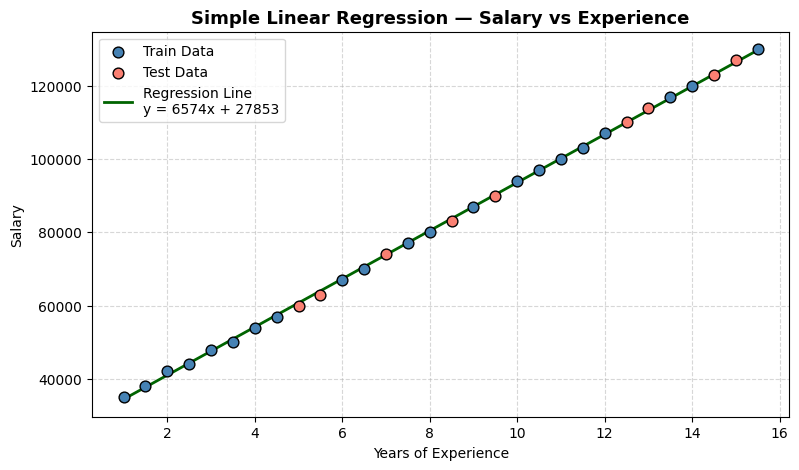

In [6]:
# (iii) PLOT — Regression Line + Actual Data Points
y_pred_test  = model.predict(X_test)   # predictions on test data
y_pred_train = model.predict(X_train)  # predictions on train data

# Line across full range
x_line = np.linspace(X['years_of_experience'].min(),X['years_of_experience'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(9, 5))

# All actual data points
plt.scatter(X_train, y_train, color='steelblue',  label='Train Data',edgecolors='black', s=60, zorder=3)
plt.scatter(X_test,  y_test,  color='salmon',     label='Test Data',edgecolors='black', s=60, zorder=3)

# Regression line
plt.plot(x_line, y_line, color='darkgreen', linewidth=2,label=f'Regression Line\ny = {slope:.0f}x + {intercept:.0f}')

plt.title('Simple Linear Regression — Salary vs Experience',fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

Salary Predictions for New Data Points
  Experience (yrs)       Predicted Salary (₹)
  3                      47,574.64
  6                      67,295.89
  10                     93,590.90
  14                     119,885.90
  20                     159,328.41


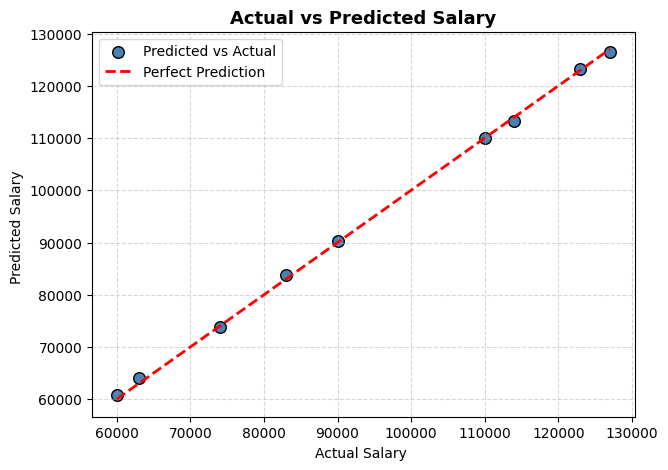

In [9]:
# (iv)  PREDICT SALARY for new data points
new_data = pd.DataFrame({'years_of_experience': [3, 6, 10, 14, 20]})
predictions = model.predict(new_data)


print("Salary Predictions for New Data Points")
print(f"  {'Experience (yrs)':<22} {'Predicted Salary (₹)'}")

for exp, sal in zip(new_data['years_of_experience'], predictions):
    print(f"  {exp:<22} {sal:,.2f}")

#  EXTRA PLOT — Actual vs Predicted  (scatter)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, color='steelblue',
            edgecolors='black', s=70, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.title('Actual vs Predicted Salary', fontsize=13, fontweight='bold')
plt.xlabel('Actual Salary ')
plt.ylabel('Predicted Salary ')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

In [10]:
# (v)  MODEL EVALUATION METRICS

mae  = mean_absolute_error(y_test, y_pred_test)
mse  = mean_squared_error(y_test,  y_pred_test)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_test)


print("  Model Evaluation Metrics (on Test Data)")
print(f"  MAE  (Mean Absolute Error)      :  {mae:,.2f}")
print(f"  MSE  (Mean Squared Error)       :  {mse:,.2f}")
print(f"  RMSE (Root Mean Squared Error)  :  {rmse:,.2f}")
print(f"  R²   (R-Squared Score)          : {r2:.4f}  ({r2*100:.2f}%)")

print("\n Interpretation:")
print(f"  → Model explains {r2*100:.2f}% of the variance in salary.")
print(f"  → On average, predictions are off by  {mae:,.0f} (MAE).")
if r2 >= 0.95:
    print("  → Excellent fit! ")
elif r2 >= 0.80:
    print("  → Good fit ")
else:
    print("  → Model needs improvement.")

  Model Evaluation Metrics (on Test Data)
  MAE  (Mean Absolute Error)      :  480.23
  MSE  (Mean Squared Error)       :  330,879.90
  RMSE (Root Mean Squared Error)  :  575.22
  R²   (R-Squared Score)          : 0.9994  (99.94%)

 Interpretation:
  → Model explains 99.94% of the variance in salary.
  → On average, predictions are off by  480 (MAE).
  → Excellent fit! 
